In [1]:
"""
The purpose of this Jupyter notebook is to evaluate the performance of
the MLP head which replaced the XGBoost head for PPI probability
prediction.

To be more precise, the performance of the MLP head is evaluated for
different modalities, which are the following:
- ordinary loss without prior correction
- ordinary loss with prior correction
- logit penalty loss without prior correction
- logit penalty loss with prior correction
"""

'\nThe purpose of this Jupyter notebook is to evaluate the performance of\nthe MLP head which replaced the XGBoost head for PPI probability\nprediction.\n\nTo be more precise, the performance of the MLP head is evaluated for\ndifferent modalities, which are the following:\n- ordinary loss without prior correction\n- ordinary loss with prior correction\n- logit penalty loss without prior correction\n- logit penalty loss with prior correction\n'

In [2]:
import os

import pandas as pd

import eval_utils as utils

# Load the Data

In [3]:
# Load the TSV file storing the test set ground truth into a DataFrame
test_ground_truth_path = (
    "/Users/jacobanter/Documents/Code/VACV_screen/Dharmacon_pooled_"
    "genome_1_and_2_subset_with_control-based_Z_scoring/probability_"
    "calibration/data_set_files/bullet-proof_test_set_without_"
    "header.tsv"
)

test_ground_truth_df = pd.read_csv(
    test_ground_truth_path,
    sep="\t",
    header=None,
    names=["protein_1", "protein_2", "label"],
    index_col=["protein_1", "protein_2"]
)

In [5]:
# Load the TSV files storing the predicted probabilties into a DataFrame
ordinary_loss_no_prior_preds_path = (
    "ordinary_loss_predictions/xCAPT5_with_MLP_interaction_probs_test_"
    "set_Sled_ckpt_seed_0_PPI_prior_None.tsv"
)
ordinary_loss_no_prior_preds_df = pd.read_csv(
    ordinary_loss_no_prior_preds_path,
    sep="\t",
    index_col=["protein_1", "protein_2"]
)

ordinary_loss_with_prior_preds_path = (
    "ordinary_loss_predictions/xCAPT5_with_MLP_interaction_probs_Sled_"
    "ckpt_bullet-proof_test_set_ordinary_loss_seed_0_PPI_prior_0.01.tsv"
)
ordinary_loss_with_prior_preds_df = pd.read_csv(
    ordinary_loss_with_prior_preds_path,
    sep="\t",
    index_col=["protein_1", "protein_2"]
)

logit_penalty_loss_no_prior_preds_path = (
    "logit_penalty_loss_predictions/xCAPT5_with_MLP_interaction_probs_"
    "Sled_ckpt_bullet-proof_test_set_logit_penalty_loss_seed_0_PPI_prior_None.tsv"
)
logit_penalty_loss_no_prior_preds_df = pd.read_csv(
    logit_penalty_loss_no_prior_preds_path,
    sep="\t",
    index_col=["protein_1", "protein_2"]
)

logit_penalty_loss_with_prior_preds_path = (
    "logit_penalty_loss_predictions/xCAPT5_with_MLP_interaction_probs_"
    "Sled_ckpt_bullet-proof_test_set_logit_penalty_loss_seed_0_PPI_prior_0.01.tsv"
)
logit_penalty_loss_with_prior_preds_df = pd.read_csv(
    logit_penalty_loss_with_prior_preds_path,
    sep="\t",
    index_col=["protein_1", "protein_2"]
)

In [6]:
# Create a directory to store the plots in
plot_dir = "performance_eval_plots"

if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

# Evaluation of Ordinary Loss without Prior Correction

In [7]:
# Create a subdirectory for this modality
ordinary_loss_without_prior_subdir = "ordinary_loss_without_prior_correction"

ordinary_loss_without_prior_path = os.path.join(
    plot_dir, ordinary_loss_without_prior_subdir
)

if not os.path.exists(ordinary_loss_without_prior_path):
    os.makedirs(ordinary_loss_without_prior_path)

### ROC Curve Generation and AUC Computation

(0.9518367346938774,
          FPR       TPR  Threshold
 0   0.000000  0.000000        inf
 1   0.000000  0.028571   0.999995
 2   0.000000  0.057143   0.999912
 3   0.000000  0.114286   0.996723
 4   0.000000  0.200000   0.994428
 5   0.000000  0.257143   0.993698
 6   0.000000  0.600000   0.804769
 7   0.028571  0.600000   0.793039
 8   0.028571  0.628571   0.722998
 9   0.028571  0.685714   0.717872
 10  0.028571  0.714286   0.706063
 11  0.085714  0.714286   0.683107
 12  0.085714  0.857143   0.530139
 13  0.114286  0.857143   0.523916
 14  0.114286  0.942857   0.517215
 15  0.371429  0.942857   0.333906
 16  0.371429  0.971429   0.245042
 17  0.428571  0.971429   0.188659
 18  0.428571  1.000000   0.184844
 19  1.000000  1.000000   0.001241)

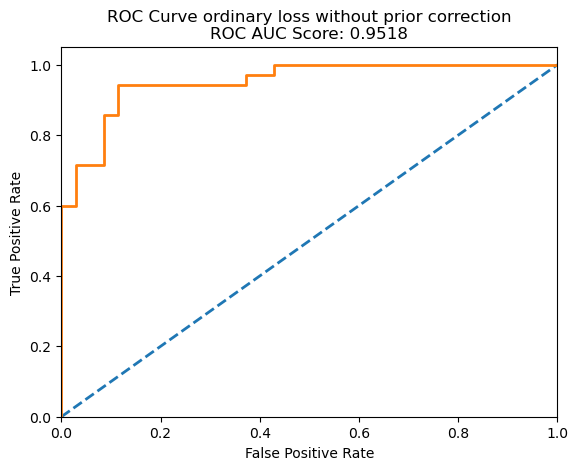

In [7]:
utils.generate_roc_curve(
    ordinary_loss_no_prior_preds_df,
    test_ground_truth_df,
    "ordinary loss without prior correction",
    os.path.join(
        ordinary_loss_without_prior_path,
        "roc_auc_test_set_ordinary_loss_without_prior_correction.png"
    )
)

### PR Curve Generation and AUC Computation

(0.9548253791366351,
       Recall  Precision  Threshold
 0   1.000000   0.500000   0.001241
 1   1.000000   0.507246   0.007749
 2   1.000000   0.514706   0.017133
 3   1.000000   0.522388   0.017480
 4   1.000000   0.530303   0.022814
 ..       ...        ...        ...
 63  0.142857   1.000000   0.995138
 64  0.114286   1.000000   0.996723
 65  0.057143   1.000000   0.999912
 66  0.028571   1.000000   0.999995
 67  0.000000   1.000000        inf
 
 [68 rows x 3 columns])

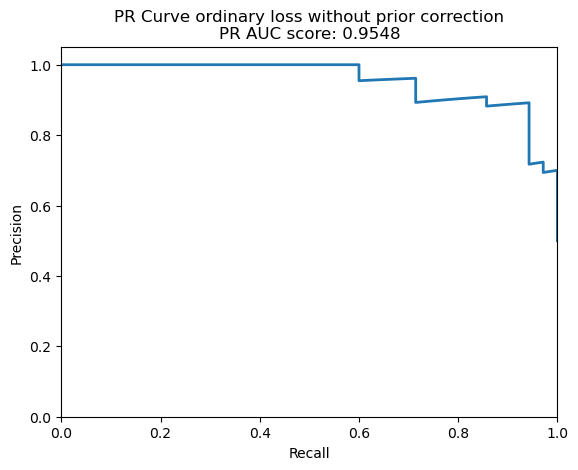

In [8]:
utils.generate_pr_curve(
    ordinary_loss_no_prior_preds_df,
    test_ground_truth_df,
    "ordinary loss without prior correction",
    os.path.join(
        ordinary_loss_without_prior_path,
        "pr_auc_test_set_ordinary_loss_without_prior_correction.png"
    )
)

### Investigating the Probability Distribution

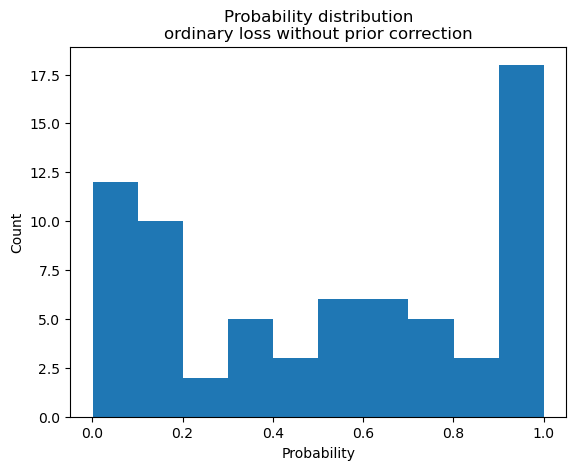

In [9]:
utils.prob_histogram(
    ordinary_loss_no_prior_preds_df,
    "ordinary loss without prior correction",
    os.path.join(
        ordinary_loss_without_prior_path,
        "prob_distr_ordinary_loss_without_prior_correction.png"
    )
)

# Evaluation of Ordinary Loss with Prior Correction

In [10]:
# Create a subdirectory for this modality
ordinary_loss_with_prior_subdir = "ordinary_loss_with_prior_correction"

ordinary_loss_with_prior_path = os.path.join(
    plot_dir, ordinary_loss_with_prior_subdir
)

if not os.path.exists(ordinary_loss_with_prior_path):
    os.makedirs(ordinary_loss_with_prior_path)

### ROC Curve Generation and AUC Computation

(0.9518367346938774,
          FPR       TPR  Threshold
 0   0.000000  0.000000        inf
 1   0.000000  0.028571   0.999507
 2   0.000000  0.057143   0.991368
 3   0.000000  0.114286   0.754455
 4   0.000000  0.200000   0.643192
 5   0.000000  0.257143   0.614293
 6   0.000000  0.600000   0.039973
 7   0.028571  0.600000   0.037263
 8   0.028571  0.628571   0.025687
 9   0.028571  0.685714   0.025058
 10  0.028571  0.714286   0.023689
 11  0.085714  0.714286   0.021310
 12  0.085714  0.857143   0.011268
 13  0.114286  0.857143   0.010994
 14  0.114286  0.942857   0.010706
 15  0.371429  0.942857   0.005038
 16  0.371429  0.971429   0.003268
 17  0.428571  0.971429   0.002343
 18  0.428571  1.000000   0.002285
 19  1.000000  1.000000   0.000013)

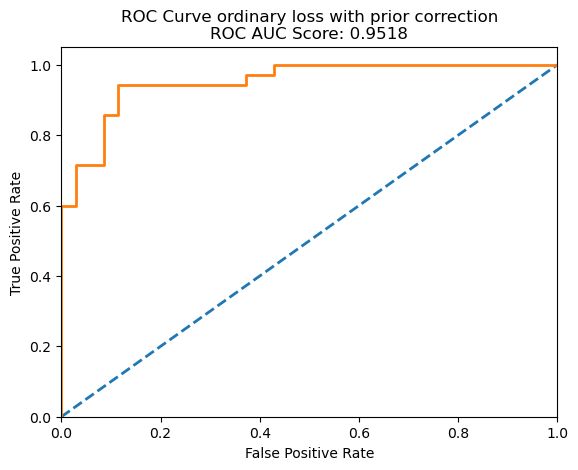

In [11]:
utils.generate_roc_curve(
    ordinary_loss_with_prior_preds_df,
    test_ground_truth_df,
    "ordinary loss with prior correction",
    os.path.join(
        ordinary_loss_with_prior_path,
        "roc_auc_test_set_ordinary_loss_with_prior_correction.png"
    )
)

### PR Curve Generation and AUC Computation

(0.9548253791366351,
       Recall  Precision  Threshold
 0   1.000000   0.500000   0.000013
 1   1.000000   0.507246   0.000079
 2   1.000000   0.514706   0.000176
 3   1.000000   0.522388   0.000180
 4   1.000000   0.530303   0.000236
 ..       ...        ...        ...
 63  0.142857   1.000000   0.674008
 64  0.114286   1.000000   0.754455
 65  0.057143   1.000000   0.991368
 66  0.028571   1.000000   0.999507
 67  0.000000   1.000000        inf
 
 [68 rows x 3 columns])

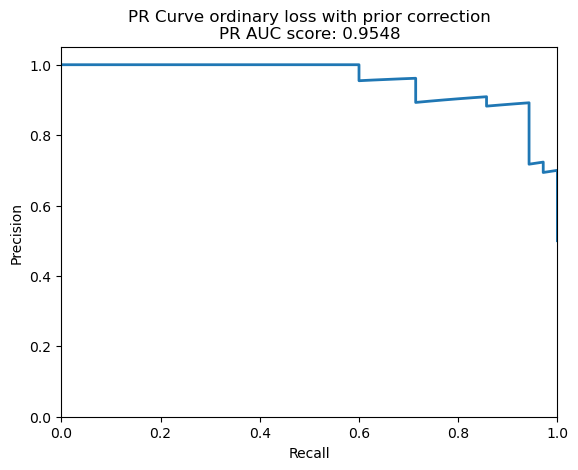

In [12]:
utils.generate_pr_curve(
    ordinary_loss_with_prior_preds_df,
    test_ground_truth_df,
    "ordinary loss with prior correction",
    os.path.join(
        ordinary_loss_with_prior_path,
        "pr_auc_test_set_ordinary_loss_with_prior_correction.png"
    )
)

### Investigating the Probability Distribution

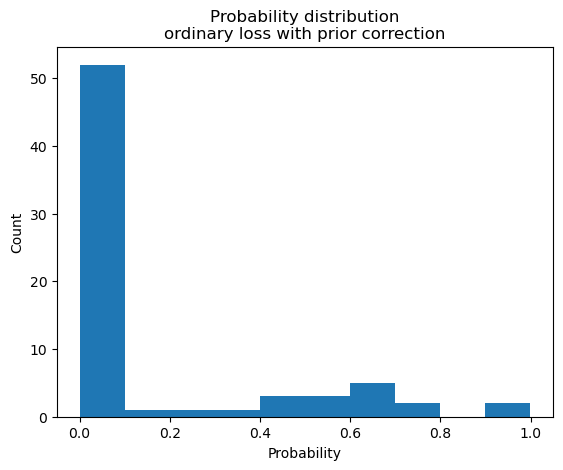

In [14]:
utils.prob_histogram(
    ordinary_loss_with_prior_preds_df,
    "ordinary loss with prior correction",
    os.path.join(
        ordinary_loss_with_prior_path,
        "prob_distr_ordinary_loss_with_prior_correction.png"
    )
)

# Evaluation of Logit Penalty Loss without Prior Correction

In [15]:
# Create a subdirectoty for this modality
logit_penalty_loss_without_prior_subdir = (
    "logit_penalty_loss_without_prior_correction"
)

logit_penalty_loss_without_prior_path = os.path.join(
    plot_dir, logit_penalty_loss_without_prior_subdir
)

if not os.path.exists(logit_penalty_loss_without_prior_path):
    os.makedirs(logit_penalty_loss_without_prior_path)

### ROC Curve Generation and AUC Computation

(0.9534693877551019,
          FPR       TPR  Threshold
 0   0.000000  0.000000        inf
 1   0.000000  0.028571   0.999956
 2   0.000000  0.085714   0.992142
 3   0.000000  0.142857   0.992057
 4   0.000000  0.200000   0.990595
 5   0.000000  0.257143   0.989945
 6   0.000000  0.600000   0.797504
 7   0.028571  0.600000   0.784599
 8   0.028571  0.628571   0.723262
 9   0.028571  0.685714   0.721186
 10  0.057143  0.685714   0.699471
 11  0.057143  0.771429   0.662347
 12  0.085714  0.771429   0.655131
 13  0.085714  0.885714   0.521701
 14  0.114286  0.885714   0.520294
 15  0.114286  0.942857   0.510448
 16  0.400000  0.942857   0.241722
 17  0.400000  1.000000   0.194033
 18  1.000000  1.000000   0.000958)

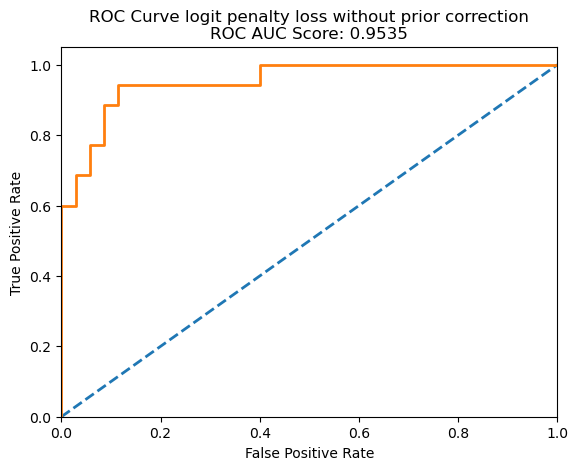

In [18]:
utils.generate_roc_curve(
    logit_penalty_loss_no_prior_preds_df,
    test_ground_truth_df,
    "logit penalty loss without prior correction",
    os.path.join(
        logit_penalty_loss_without_prior_path,
        "roc_auc_test_set_logit_penalty_loss_without_prior_correction.png"
    )
)

### PR Curve Generation and AUC Computation

(0.9563511274235031,
       Recall  Precision  Threshold
 0   1.000000   0.500000   0.000958
 1   1.000000   0.507246   0.006896
 2   1.000000   0.514706   0.017654
 3   1.000000   0.522388   0.017946
 4   1.000000   0.530303   0.018043
 ..       ...        ...        ...
 63  0.142857   1.000000   0.992057
 64  0.085714   1.000000   0.992142
 65  0.057143   1.000000   0.999699
 66  0.028571   1.000000   0.999956
 67  0.000000   1.000000        inf
 
 [68 rows x 3 columns])

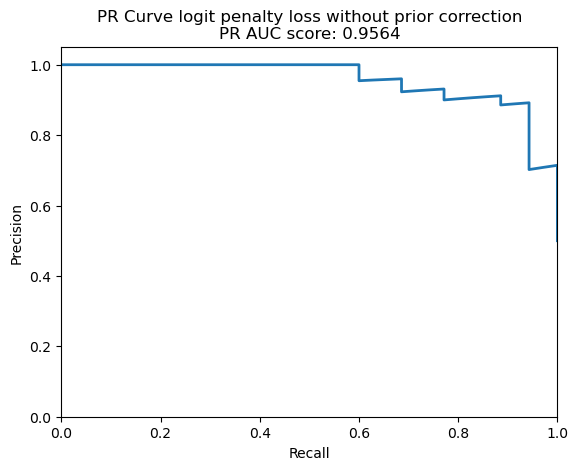

In [19]:
utils.generate_pr_curve(
    logit_penalty_loss_no_prior_preds_df,
    test_ground_truth_df,
    "logit penalty loss without prior correction",
    os.path.join(
        logit_penalty_loss_without_prior_path,
        "pr_auc_test_set_logit_penalty_loss_without_prior_correction.png"
    )
)

### Investigating the Probability Distribution

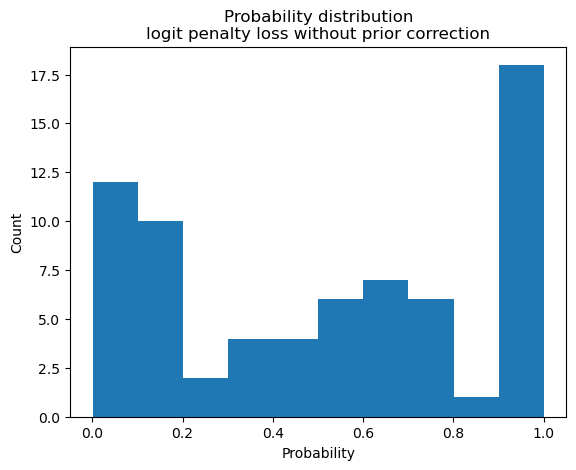

In [20]:
utils.prob_histogram(
    logit_penalty_loss_no_prior_preds_df,
    "logit penalty loss without prior correction",
    os.path.join(
        logit_penalty_loss_without_prior_path,
        "prob_distr_logit_penalty_loss_without_prior_correction.png"
    )
)

# Evaluation of Logit Penalty Loss with Prior Correction

In [21]:
# Create a subdirectory for this modality
logit_penalty_loss_with_prior_subdir = (
    "logit_penalty_loss_with_prior_correction"
)

logit_penalty_loss_with_prior_path = os.path.join(
    plot_dir, logit_penalty_loss_with_prior_subdir
)

if not os.path.exists(logit_penalty_loss_with_prior_path):
    os.makedirs(logit_penalty_loss_with_prior_path)

### ROC Curve Generation and AUC Computation

(0.9534693877551019,
          FPR       TPR  Threshold
 0   0.000000  0.000000        inf
 1   0.000000  0.028571   0.995704
 2   0.000000  0.085714   0.560493
 3   0.000000  0.142857   0.557830
 4   0.000000  0.200000   0.515489
 5   0.000000  0.257143   0.498603
 6   0.000000  0.600000   0.038259
 7   0.028571  0.600000   0.035487
 8   0.028571  0.628571   0.025720
 9   0.028571  0.685714   0.025462
 10  0.057143  0.685714   0.022970
 11  0.057143  0.771429   0.019429
 12  0.085714  0.771429   0.018827
 13  0.085714  0.885714   0.010898
 14  0.114286  0.885714   0.010837
 15  0.114286  0.942857   0.010422
 16  0.400000  0.942857   0.003210
 17  0.400000  1.000000   0.002426
 18  1.000000  1.000000   0.000010)

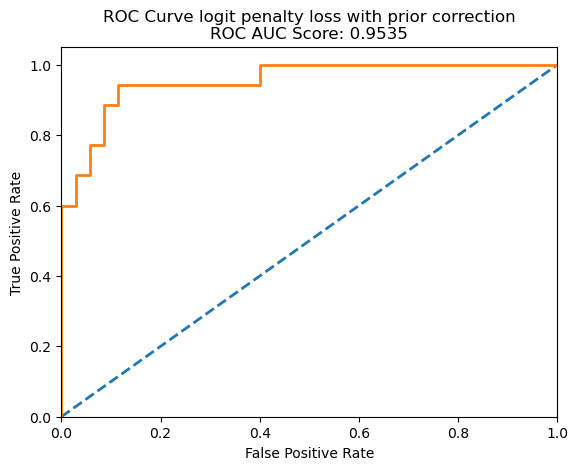

In [23]:
utils.generate_roc_curve(
    logit_penalty_loss_with_prior_preds_df,
    test_ground_truth_df,
    "logit penalty loss with prior correction",
    os.path.join(
        logit_penalty_loss_with_prior_path,
        "roc_auc_test_set_logit_penalty_loss_with_prior_correction.png"
    )
)

### PR Curve Generation and AUC Computation

(0.9563511274235031,
       Recall  Precision  Threshold
 0   1.000000   0.500000   0.000010
 1   1.000000   0.507246   0.000070
 2   1.000000   0.514706   0.000181
 3   1.000000   0.522388   0.000185
 4   1.000000   0.530303   0.000186
 ..       ...        ...        ...
 63  0.142857   1.000000   0.557830
 64  0.085714   1.000000   0.560493
 65  0.057143   1.000000   0.971069
 66  0.028571   1.000000   0.995704
 67  0.000000   1.000000        inf
 
 [68 rows x 3 columns])

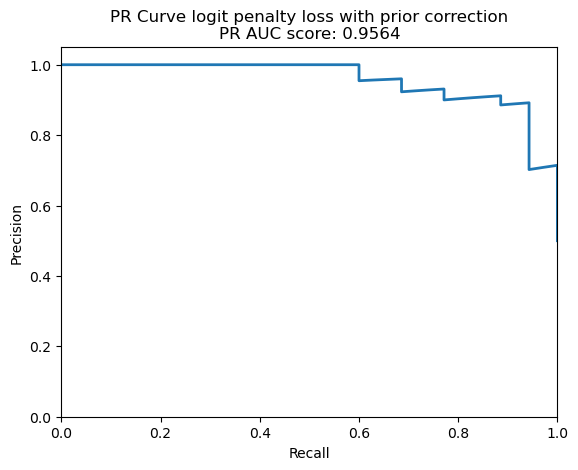

In [24]:
utils.generate_pr_curve(
    logit_penalty_loss_with_prior_preds_df,
    test_ground_truth_df,
    "logit penalty loss with prior correction",
    os.path.join(
        logit_penalty_loss_with_prior_path,
        "pr_auc_test_set_logit_penalty_loss_with_prior_correction.png"
    )
)

### Investigating the Probability Distribution

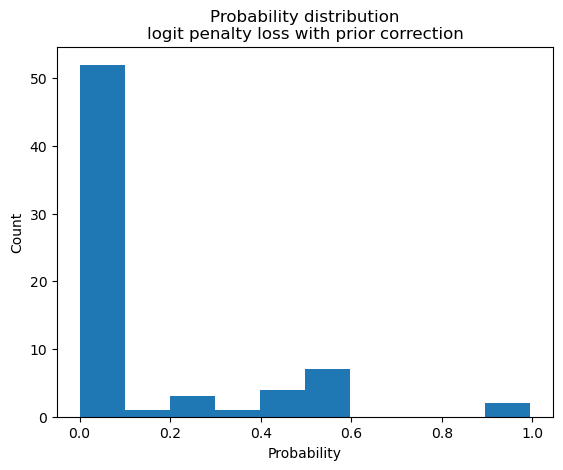

In [25]:
utils.prob_histogram(
    logit_penalty_loss_with_prior_preds_df,
    "logit penalty loss with prior correction",
    os.path.join(
        logit_penalty_loss_with_prior_path,
        "prob_distr_logit_penalty_loss_with_prior_correction.png"
    )
)

# Evaluation of the five Random Seeds

## Evaluation for the Sled Checkpoint

In [10]:
# Above, the test set ground truth TSV file has been loaded without
# header
# Define the path to the TSV file with header
test_ground_truth_path = (
    "/Users/jacobanter/Documents/Code/VACV_screen/HVIDB_pos_instances_"
    "with_nucleolus_neg_instances/new_combined_data_set_creation/data_"
    "set_files/bullet-proof_test_set.tsv"
)

In [11]:
utils.evaluation_k_fold_cross_validation(
    test_ground_truth_path,
    os.path.join(
        "ordinary_loss_predictions",
         "xCAPT5_with_MLP_interaction_probs_test_set_Sled_ckpt_seed_"
         "{i}_PPI_prior_None.tsv"
    ),
    5,
    "interaction_probability",
    "Sled checkpoint",
    "evaluation_Sled_ckpt_ordinary_loss_five_random_seeds.txt"
)

Using 5-fold cross-validation, the metrics for Sled checkpoint are as follows:
Accuracy:      0.8571428571428573 ± 0.025555062599997593
Precision:     0.8211471245681772 ± 0.026984064919755375
Recall:        0.9142857142857143 ± 0.03614031611621006
F1-score:      0.8647801696020874 ± 0.02475822237550206
Specificity:   0.8 ± 0.036140316116210026
MCC:           0.7199660420831788 ± 0.051080776852167366
ROC AUC score: 0.9307755102040816 ± 0.011698275342153657
AUPRC score    0.9363819612321942 ± 0.011182067009864667


((0.8571428571428573, 0.025555062599997593),
 (0.8211471245681772, 0.026984064919755375),
 (0.9142857142857143, 0.03614031611621006),
 (0.8647801696020874, 0.02475822237550206),
 (0.8, 0.036140316116210026),
 (0.7199660420831788, 0.051080776852167366),
 (0.9307755102040816, 0.011698275342153657),
 (0.9363819612321942, 0.011182067009864667))

## Evaluation for the Pan Checkpoint

In [12]:
utils.evaluation_k_fold_cross_validation(
    test_ground_truth_path,
    os.path.join(
        "ordinary_loss_predictions",
        "xCAPT5_with_MLP_interaction_probs_test_set_Pan_ckpt_seed_{i}_"
        "PPI_prior_None.tsv"
    ),
    5,
    "interaction_probability",
    "Pan checkpoint",
    "evaluation_Pan_ckpt_ordinary_loss_five_random_seeds.txt"
)

Using 5-fold cross-validation, the metrics for Pan checkpoint are as follows:
Accuracy:      0.8057142857142857 ± 0.029416086117105732
Precision:     0.8562698412698413 ± 0.03581150788154289
Recall:        0.7371428571428573 ± 0.06363159271805742
F1-score:      0.7902481918659098 ± 0.03672302388267197
Specificity:   0.8742857142857142 ± 0.03875617133214435
MCC:           0.6195273139762157 ± 0.056816201717274584
ROC AUC score: 0.8635102040816328 ± 0.012629603007878324
AUPRC score    0.8431457753490628 ± 0.008085023850803294


((0.8057142857142857, 0.029416086117105732),
 (0.8562698412698413, 0.03581150788154289),
 (0.7371428571428573, 0.06363159271805742),
 (0.7902481918659098, 0.03672302388267197),
 (0.8742857142857142, 0.03875617133214435),
 (0.6195273139762157, 0.056816201717274584),
 (0.8635102040816328, 0.012629603007878324),
 (0.8431457753490628, 0.008085023850803294))